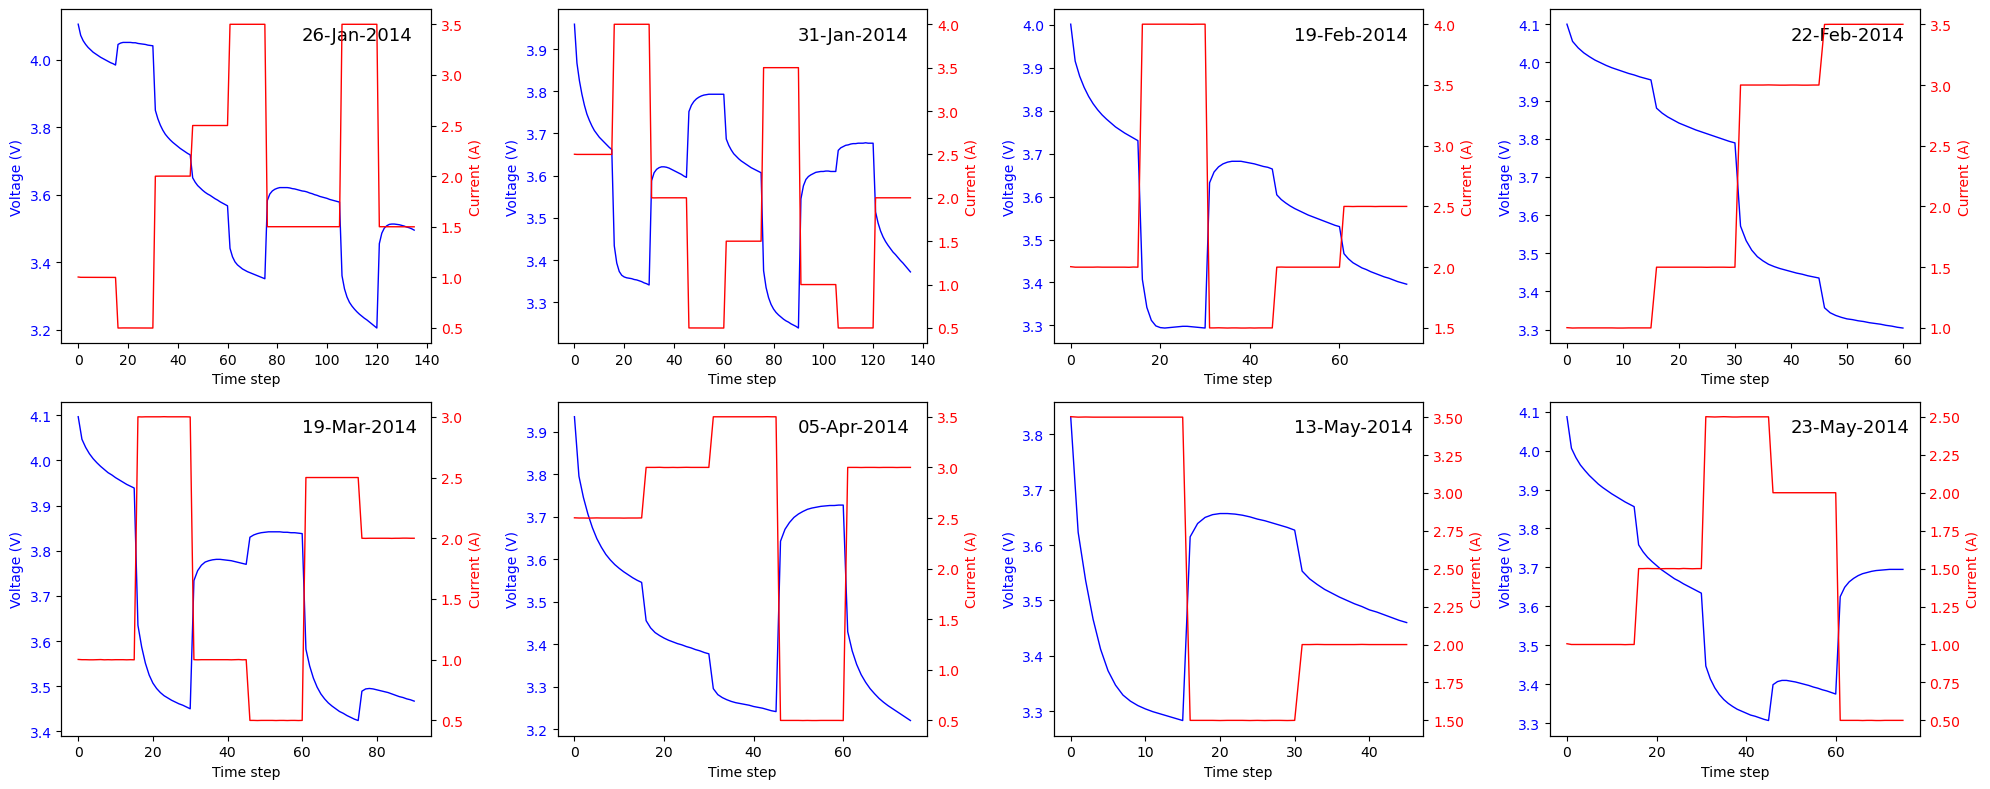

In [99]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Directory containing your run_XXX.npz files
npz_dir = "data/"  # <-- replace with your actual path

# 1) List all .npz files in the directory
all_files = [f for f in os.listdir(npz_dir) if f.endswith(".npz")]
if len(all_files) < 8:
    raise RuntimeError(f"Need at least 8 .npz files, found only {len(all_files)}.")

# 2) Randomly sample 8 files
sampled = random.sample(all_files, 8)

# 3) Sort these 8 files chronologically by their “01-Jan-2014 HH:MM:SS” date
dated_list = []
for fn in sampled:
    data = np.load(os.path.join(npz_dir, fn))
    date_str_full = str(data["date"].item())            # e.g. "01-Jan-2014 18:08:30"
    date_obj = datetime.strptime(date_str_full, "%d-%b-%Y %H:%M:%S")
    dated_list.append((fn, date_obj))

dated_list.sort(key=lambda x: x[1])
selected_files = [fn for fn, _ in dated_list]

# 4) Create a 2×4 subplot (two rows, four columns)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 8), sharex=False)

for idx, fn in enumerate(selected_files):
    row = idx // 4
    col = idx % 4
    ax_volt = axes[row, col]
    
    # 5a) Load current and voltage from the .npz
    data = np.load(os.path.join(npz_dir, fn))
    curr = data["current"].astype(np.float32)  # shape (T,)
    volt = data["voltage"].astype(np.float32)  # shape (T,)
    date_str_full = str(data["date"].item())   # e.g. "01-Jan-2014 18:08:30"
    date_str = date_str_full.split()[0]        # keep only "01-Jan-2014"
    
    # 5b) Time axis (integer timesteps)
    t = np.arange(len(volt))
    
    # 5c) Plot voltage (blue) on the left y‐axis
    ax_volt.plot(t, volt, color="blue", linewidth=1.0, label="Voltage")
    ax_volt.set_ylabel("Voltage (V)", color="blue")
    ax_volt.tick_params(axis="y", labelcolor="blue")
    ax_volt.set_xlabel("Time step")
    
    # 5d) Create a twin y‐axis for current (red)
    ax_curr = ax_volt.twinx()
    ax_curr.plot(t, curr, color="red", linewidth=1.0, label="Current")
    ax_curr.set_ylabel("Current (A)", color="red")
    ax_curr.tick_params(axis="y", labelcolor="red")
    
    # 5e) Annotate the date inside the plot (top‐left corner)
    ax_volt.text(
        0.65, 0.95,      # x‐fraction, y‐fraction inside axes
        date_str,
        transform=ax_volt.transAxes,
        fontsize=13,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="white", alpha=0.7)
    )
    
    # 5f) Combine legends from both axes (only once per subplot)
    # lines_volt, labels_volt = ax_volt.get_legend_handles_labels()
    # lines_curr, labels_curr = ax_curr.get_legend_handles_labels()
    # ax_volt.legend(
    #     lines_volt + lines_curr,
    #     labels_volt + labels_curr,
    #     loc="upper right",
    #     fontsize=7
    # )

# 6) Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig(f"battNN_viz.png", dpi=300, bbox_inches='tight')
plt.show()